# TelecomX — Análisis de Evasión de Clientes

Este notebook forma parte del Challenge 2 de Data Science de Alura LATAM. La idea es analizar los datos de clientes de Telecom X y tratar de entender por qué algunos se van y otros se quedan. A partir de eso, el equipo de ciencia de datos puede construir modelos o pensar estrategias para retener más clientes.

Voy a seguir el proceso de ETL (extraer, transformar y cargar los datos), hacer una limpieza, explorar las variables y al final armar un informe con lo que encontré.


## 1. Librerías y configuración inicial

Primero importo todo lo que voy a necesitar. Uso pandas para manejar los datos, matplotlib y seaborn para los gráficos, y requests para traer los datos desde la API.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import warnings

warnings.filterwarnings('ignore')

# configuración básica para los gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11


## 2. Extracción de datos

Los datos están disponibles en un archivo JSON en GitHub. Los cargo directamente desde la URL usando requests, así no tengo que descargar nada a mano.


In [2]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

respuesta = requests.get(url)
datos_json = respuesta.json()

# el JSON puede tener estructura anidada, json_normalize lo aplana
df = pd.json_normalize(datos_json)

print(f"Datos cargados. Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()


Datos cargados. Filas: 7267 | Columnas: 21


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## 3. Primera mirada a los datos

Antes de limpiar cualquier cosa, me conviene ver qué tipos de datos hay, cuántas columnas existen y cómo lucen las primeras filas.


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [4]:
print("Valores únicos por columna de texto:")
for col in df.select_dtypes(include='object').columns:
    print(f"  {col}: {df[col].unique()}")


Valores únicos por columna de texto:
  customerID: ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
  Churn: ['No' 'Yes' '']
  customer.gender: ['Female' 'Male']
  customer.Partner: ['Yes' 'No']
  customer.Dependents: ['Yes' 'No']
  phone.PhoneService: ['Yes' 'No']
  phone.MultipleLines: ['No' 'Yes' 'No phone service']
  internet.InternetService: ['DSL' 'Fiber optic' 'No']
  internet.OnlineSecurity: ['No' 'Yes' 'No internet service']
  internet.OnlineBackup: ['Yes' 'No' 'No internet service']
  internet.DeviceProtection: ['No' 'Yes' 'No internet service']
  internet.TechSupport: ['Yes' 'No' 'No internet service']
  internet.StreamingTV: ['Yes' 'No' 'No internet service']
  internet.StreamingMovies: ['No' 'Yes' 'No internet service']
  account.Contract: ['One year' 'Month-to-month' 'Two year']
  account.PaperlessBilling: ['Yes' 'No']
  account.PaymentMethod: ['Mailed check' 'Electronic check' 'Credit card (automatic)'
 'Bank transfer (automatic)']
  a

## 4. Revisión de inconsistencias

Acá busco tres cosas principalmente: valores nulos, filas duplicadas y posibles errores en las categorías (por ejemplo mayúsculas mezcladas, espacios de más, etc.).


In [5]:
# nulos
nulos = df.isnull().sum()
print("Columnas con valores nulos:")
print(nulos[nulos > 0])

# strings vacíos (a veces los nulos vienen como "")
vacios = (df == '').sum()
print("\nColumnas con strings vacíos:")
print(vacios[vacios > 0])

# duplicados
print(f"\nFilas duplicadas: {df.duplicated().sum()}")


Columnas con valores nulos:
Series([], dtype: int64)

Columnas con strings vacíos:
Churn    224
dtype: int64

Filas duplicadas: 0


## 5. Limpieza de datos

Con lo que encontré arriba, aplico las correcciones necesarias. Normalizo los textos, convierto columnas numéricas que venían como strings, relleno los nulos donde tiene sentido y elimino duplicados.


In [6]:
# trabajo sobre una copia para no pisar los datos originales
df_limpio = df.copy()

# normalizar nombres de columnas
df_limpio.columns = [c.strip().replace(' ', '_') for c in df_limpio.columns]

# pasar strings a minúsculas y sin espacios extra
for col in df_limpio.select_dtypes(include='object').columns:
    df_limpio[col] = df_limpio[col].astype(str).str.strip().str.lower()

# reemplazar vacíos y "nan" por NaN real
df_limpio.replace({'': np.nan, 'nan': np.nan}, inplace=True)

# convertir columnas de cargos a numérico
for col in df_limpio.columns:
    if 'charge' in col.lower() or 'charges' in col.lower():
        df_limpio[col] = pd.to_numeric(df_limpio[col], errors='coerce')

# los nulos en TotalCharges probablemente son clientes nuevos sin historial, los pongo en 0
total_cols = [c for c in df_limpio.columns if 'total' in c.lower()]
for col in total_cols:
    df_limpio[col].fillna(0, inplace=True)

# eliminar duplicados
antes = len(df_limpio)
df_limpio.drop_duplicates(inplace=True)
df_limpio.reset_index(drop=True, inplace=True)
print(f"Duplicados eliminados: {antes - len(df_limpio)}")
print(f"Filas finales: {len(df_limpio)}")


Duplicados eliminados: 0
Filas finales: 7267


## 6. Estandarización y traducción de columnas

Para que sea más fácil de leer y presentar, renombro las columnas al español y convierto los valores "yes/no" a 1 y 0. Esto también es útil si después se quiere usar el dataset en un modelo.


In [7]:
# renombrar columnas
nombres = {}
for col in df_limpio.columns:
    c = col.lower()
    if 'customerid' in c:          nombres[col] = 'id_cliente'
    elif 'gender' in c:            nombres[col] = 'genero'
    elif 'seniorcitizen' in c:     nombres[col] = 'adulto_mayor'
    elif 'partner' in c:           nombres[col] = 'tiene_pareja'
    elif 'dependent' in c:         nombres[col] = 'tiene_dependientes'
    elif 'tenure' in c:            nombres[col] = 'meses_contrato'
    elif 'phoneservice' in c:      nombres[col] = 'servicio_telefono'
    elif 'multiplelines' in c:     nombres[col] = 'lineas_multiples'
    elif 'internetservice' in c:   nombres[col] = 'tipo_internet'
    elif 'onlinesecurity' in c:    nombres[col] = 'seguridad_online'
    elif 'onlinebackup' in c:      nombres[col] = 'backup_online'
    elif 'deviceprotection' in c:  nombres[col] = 'proteccion_dispositivo'
    elif 'techsupport' in c:       nombres[col] = 'soporte_tecnico'
    elif 'streamingtv' in c:       nombres[col] = 'streaming_tv'
    elif 'streamingmovies' in c:   nombres[col] = 'streaming_peliculas'
    elif 'contract' in c:          nombres[col] = 'tipo_contrato'
    elif 'paperlessbilling' in c:  nombres[col] = 'factura_digital'
    elif 'paymentmethod' in c:     nombres[col] = 'metodo_pago'
    elif 'monthly' in c:           nombres[col] = 'cargo_mensual'
    elif 'total' in c and 'charge' in c: nombres[col] = 'cargo_total'
    elif 'churn' in c:             nombres[col] = 'evasion'

df_limpio.rename(columns=nombres, inplace=True)
print("Columnas actualizadas:", list(df_limpio.columns))


Columnas actualizadas: ['id_cliente', 'evasion', 'genero', 'adulto_mayor', 'tiene_pareja', 'tiene_dependientes', 'meses_contrato', 'servicio_telefono', 'lineas_multiples', 'tipo_internet', 'seguridad_online', 'backup_online', 'proteccion_dispositivo', 'soporte_tecnico', 'streaming_tv', 'streaming_peliculas', 'tipo_contrato', 'factura_digital', 'metodo_pago', 'cargo_mensual', 'cargo_total']


In [8]:
# convertir yes/no a 1/0
binarias = ['evasion', 'tiene_pareja', 'tiene_dependientes',
            'servicio_telefono', 'factura_digital', 'adulto_mayor']

mapa = {'yes': 1, 'no': 0, '1': 1, '0': 0}
for col in binarias:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].map(mapa)

# traducir género
if 'genero' in df_limpio.columns:
    df_limpio['genero'] = df_limpio['genero'].map({'male': 'masculino', 'female': 'femenino'})

df_limpio.head(3)


,id_cliente,evasion,genero,adulto_mayor,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefono,lineas_multiples,tipo_internet,...,backup_online,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_digital,metodo_pago,cargo_mensual,cargo_total
0,0002-orfbo,0.0,femenino,NaN,1,1,9,1,no,dsl,...,yes,no,yes,yes,no,one year,1,mailed check,65.6,593.30
1,0003-mknfe,0.0,masculino,NaN,0,0,9,1,yes,dsl,...,no,no,no,no,yes,month-to-month,0,mailed check,59.9,542.40
2,0004-tlhlj,1.0,masculino,NaN,0,0,4,1,no,fiber optic,...,no,yes,no,no,no,month-to-month,1,electronic check,73.9,280.85


## 7. Nueva columna: cargo diario

Divido el cargo mensual entre 30 para tener una referencia del gasto diario. No es una variable imprescindible pero puede ser útil para comparar clientes con distintos planes.


In [9]:
if 'cargo_mensual' in df_limpio.columns:
    df_limpio['cargo_diario'] = (df_limpio['cargo_mensual'] / 30).round(4)
    print("Columna cargo_diario creada correctamente.")
    print(df_limpio[['cargo_mensual', 'cargo_diario']].describe().round(2))


Columna cargo_diario creada correctamente.
       cargo_mensual  cargo_diario
count        7267.00       7267.00
mean           64.72          2.16
std            30.13          1.00
min            18.25          0.61
25%            35.42          1.18
50%            70.30          2.34
75%            89.88          3.00
max           118.75          3.96


## 8. Análisis descriptivo

Acá veo las estadísticas básicas de las variables numéricas y también calculo la tasa de evasión general para tener contexto antes de los gráficos.


In [10]:
df_limpio.describe().round(2)


,evasion,adulto_mayor,tiene_pareja,tiene_dependientes,meses_contrato,servicio_telefono,factura_digital,cargo_mensual,cargo_total,cargo_diario
count,7043.00,0.0,7267.00,7267.00,7267.00,7267.0,7267.00,7267.00,7267.00,7267.00
mean,0.27,NaN,0.48,0.30,32.35,0.9,0.59,64.72,2277.18,2.16
std,0.44,NaN,0.50,0.46,24.57,0.3,0.49,30.13,2268.65,1.00
min,0.00,NaN,0.00,0.00,0.00,0.0,0.00,18.25,0.00,0.61
25%,0.00,NaN,0.00,0.00,9.00,1.0,0.00,35.42,396.20,1.18
50%,0.00,NaN,0.00,0.00,29.00,1.0,1.00,70.30,1389.20,2.34
75%,1.00,NaN,1.00,1.00,55.00,1.0,1.00,89.88,3778.52,3.00
max,1.00,NaN,1.00,1.00,72.00,1.0,1.00,118.75,8684.80,3.96


In [11]:
if 'evasion' in df_limpio.columns:
    total = len(df_limpio)
    se_fueron = int(df_limpio['evasion'].sum())
    se_quedaron = total - se_fueron
    tasa = se_fueron / total * 100

    print(f"Total de clientes:      {total:,}")
    print(f"Se fueron:              {se_fueron:,}")
    print(f"Se quedaron:            {se_quedaron:,}")
    print(f"Tasa de evasión:        {tasa:.1f}%")


Total de clientes:      7,267
Se fueron:              1,869
Se quedaron:            5,398
Tasa de evasión:        25.7%


## 9. Distribución de la evasión

Primero quiero ver visualmente cuántos clientes se fueron vs cuántos se quedaron. Uso un gráfico de torta y uno de barras para verlo desde dos ángulos.


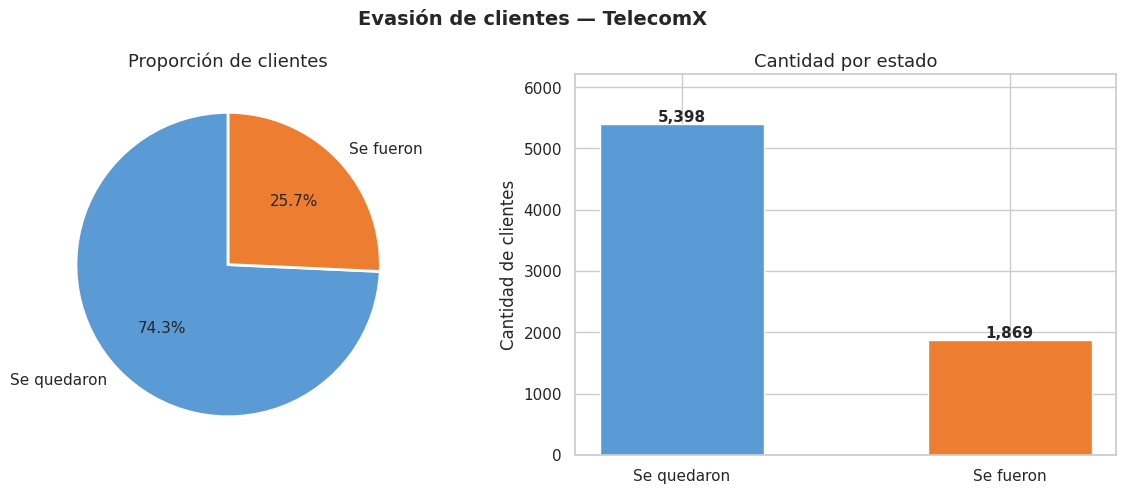

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

etiquetas = ['Se quedaron', 'Se fueron']
colores = ['#5B9BD5', '#ED7D31']
valores = [se_quedaron, se_fueron]

# torta
ax1.pie(valores, labels=etiquetas, autopct='%1.1f%%',
        colors=colores, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Proporción de clientes', fontsize=13)

# barras
barras = ax2.bar(etiquetas, valores, color=colores, width=0.5, edgecolor='white')
for b, v in zip(barras, valores):
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 40,
             f'{v:,}', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Cantidad de clientes')
ax2.set_ylim(0, max(valores) * 1.15)
ax2.set_title('Cantidad por estado', fontsize=13)

fig.suptitle('Evasión de clientes — TelecomX', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_evasion.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Evasión por variables categóricas

Me interesa saber si variables como el tipo de contrato, el método de pago o el tipo de internet tienen relación con la evasión. Calculo la tasa de churn para cada categoría y lo grafico.


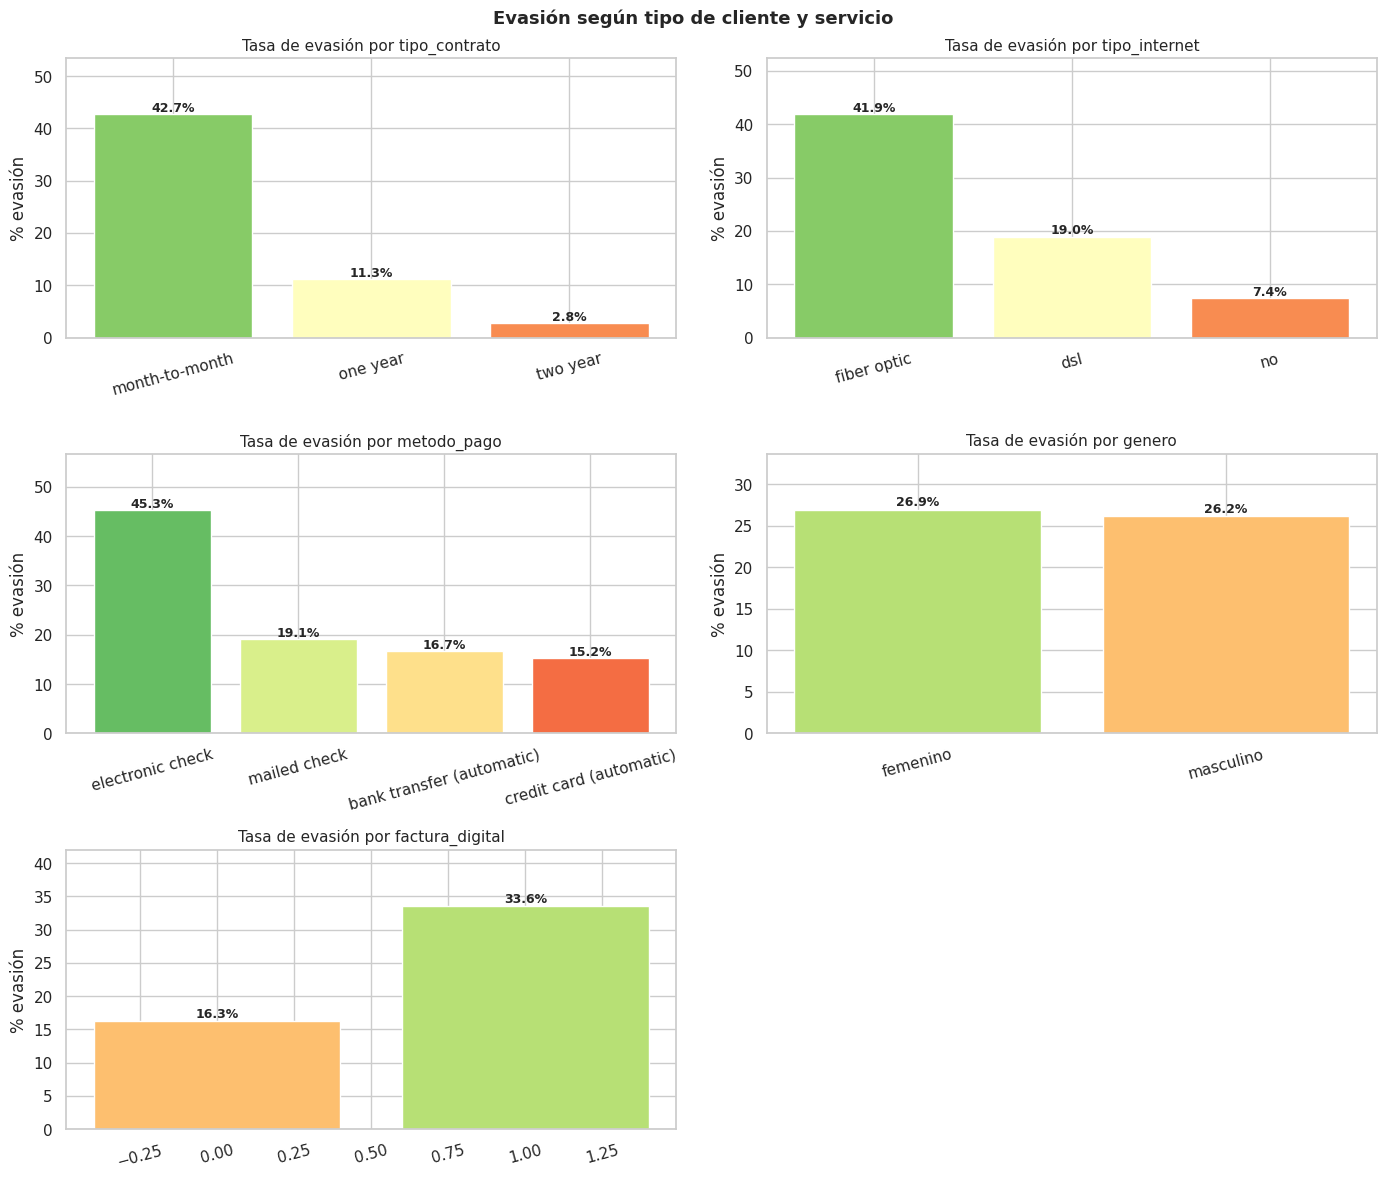

In [13]:
categoricas = ['tipo_contrato', 'tipo_internet', 'metodo_pago', 'genero', 'factura_digital']
categoricas = [v for v in categoricas if v in df_limpio.columns]

filas = (len(categoricas) + 1) // 2
fig, axes = plt.subplots(filas, 2, figsize=(14, 4 * filas))
axes = axes.flatten()

for i, var in enumerate(categoricas):
    tasa_var = df_limpio.groupby(var)['evasion'].mean().sort_values(ascending=False) * 100
    barras = axes[i].bar(tasa_var.index, tasa_var.values,
                         color=sns.color_palette("RdYlGn_r", len(tasa_var)),
                         edgecolor='white')
    for b, v in zip(barras, tasa_var.values):
        axes[i].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                     f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
    axes[i].set_title(f'Tasa de evasión por {var}', fontsize=11)
    axes[i].set_ylabel('% evasión')
    axes[i].set_ylim(0, tasa_var.max() * 1.25)
    axes[i].tick_params(axis='x', rotation=15)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Evasión según tipo de cliente y servicio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_categoricas.png', dpi=150, bbox_inches='tight')
plt.show()


In [14]:
# tabla resumen para las variables binarias
extras = ['adulto_mayor', 'tiene_pareja', 'tiene_dependientes',
          'soporte_tecnico', 'seguridad_online', 'backup_online']
extras = [c for c in extras if c in df_limpio.columns]

resumen = {}
for var in extras:
    grupo = df_limpio.groupby(var)['evasion'].mean() * 100
    resumen[var] = grupo.rename({0: 'No', 1: 'Sí'})

print("Tasa de evasión (%) según servicios adicionales y perfil:")
pd.DataFrame(resumen).T.round(1)


Tasa de evasión (%) según servicios adicionales y perfil:


,No,Sí,no,no internet service,yes
adulto_mayor,NaN,NaN,NaN,NaN,NaN
tiene_pareja,33.0,19.7,NaN,NaN,NaN
tiene_dependientes,31.3,15.5,NaN,NaN,NaN
soporte_tecnico,NaN,NaN,41.6,7.4,15.2
seguridad_online,NaN,NaN,41.8,7.4,14.6
backup_online,NaN,NaN,39.9,7.4,21.5


## 11. Evasión por variables numéricas

Ahora veo cómo se distribuyen las variables numéricas (meses de contrato, cargos) entre los clientes que se fueron y los que no. Los boxplots son útiles para esto porque muestran la mediana y los valores extremos.


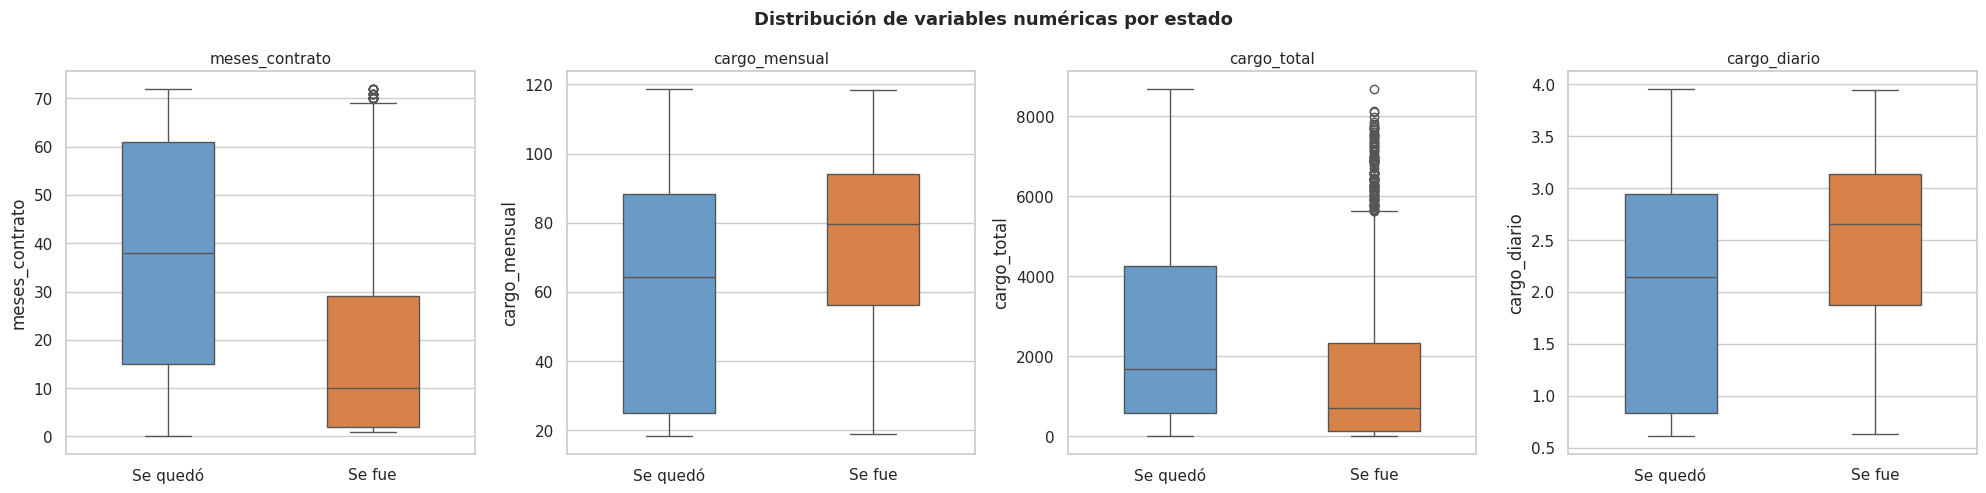

In [15]:
numericas = ['meses_contrato', 'cargo_mensual', 'cargo_total', 'cargo_diario']
numericas = [v for v in numericas if v in df_limpio.columns]

fig, axes = plt.subplots(1, len(numericas), figsize=(5 * len(numericas), 5))
if len(numericas) == 1:
    axes = [axes]

paleta = {0: '#5B9BD5', 1: '#ED7D31'}

for i, var in enumerate(numericas):
    temp = df_limpio[[var, 'evasion']].dropna()
    temp['estado'] = temp['evasion'].map({0: 'Se quedó', 1: 'Se fue'})
    sns.boxplot(data=temp, x='estado', y=var, ax=axes[i],
                palette={'Se quedó': '#5B9BD5', 'Se fue': '#ED7D31'},
                width=0.45)
    axes[i].set_title(var, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de variables numéricas por estado', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_numericas.png', dpi=150, bbox_inches='tight')
plt.show()


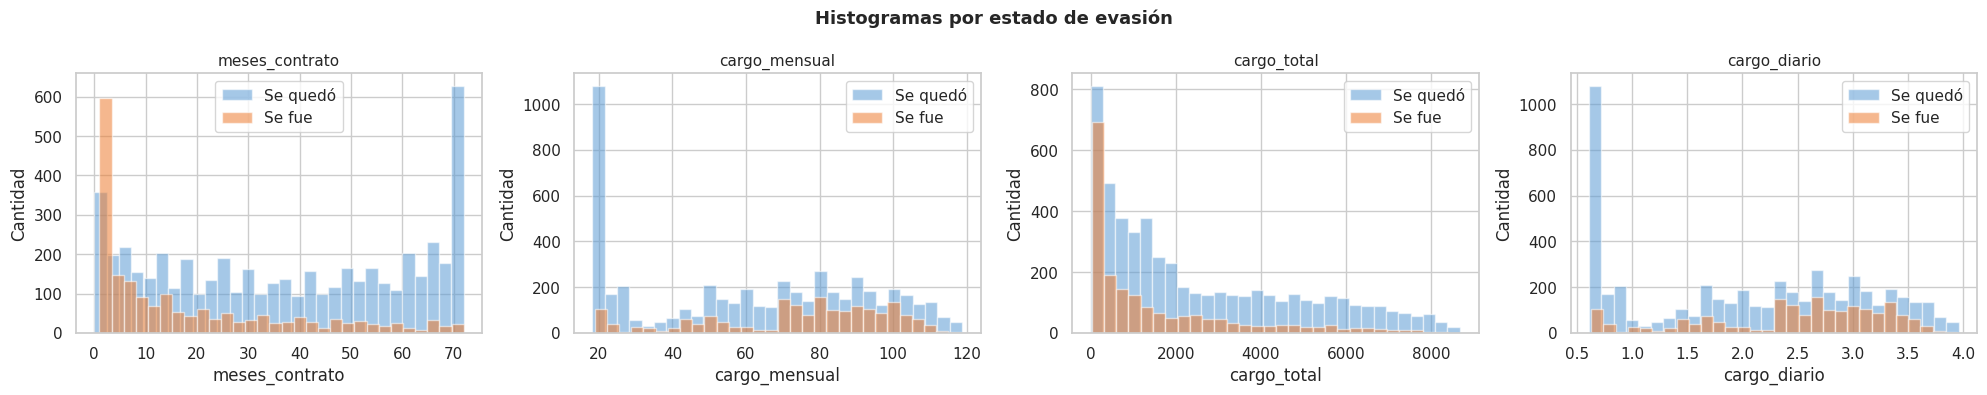

In [16]:
# histogramas superpuestos para ver la distribución más en detalle
fig, axes = plt.subplots(1, len(numericas), figsize=(5 * len(numericas), 4))
if len(numericas) == 1:
    axes = [axes]

for i, var in enumerate(numericas):
    for estado, color, nombre in [(0, '#5B9BD5', 'Se quedó'), (1, '#ED7D31', 'Se fue')]:
        subset = df_limpio[df_limpio['evasion'] == estado][var].dropna()
        axes[i].hist(subset, bins=30, alpha=0.55, color=color, label=nombre, edgecolor='white')
    axes[i].set_title(var, fontsize=11)
    axes[i].legend()
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Cantidad')

plt.suptitle('Histogramas por estado de evasión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Correlación entre variables (extra)

Por último armo un mapa de calor con las correlaciones entre variables numéricas. Esto ayuda a ver qué tan relacionadas están entre sí y cuáles tienen más vínculo con la evasión.


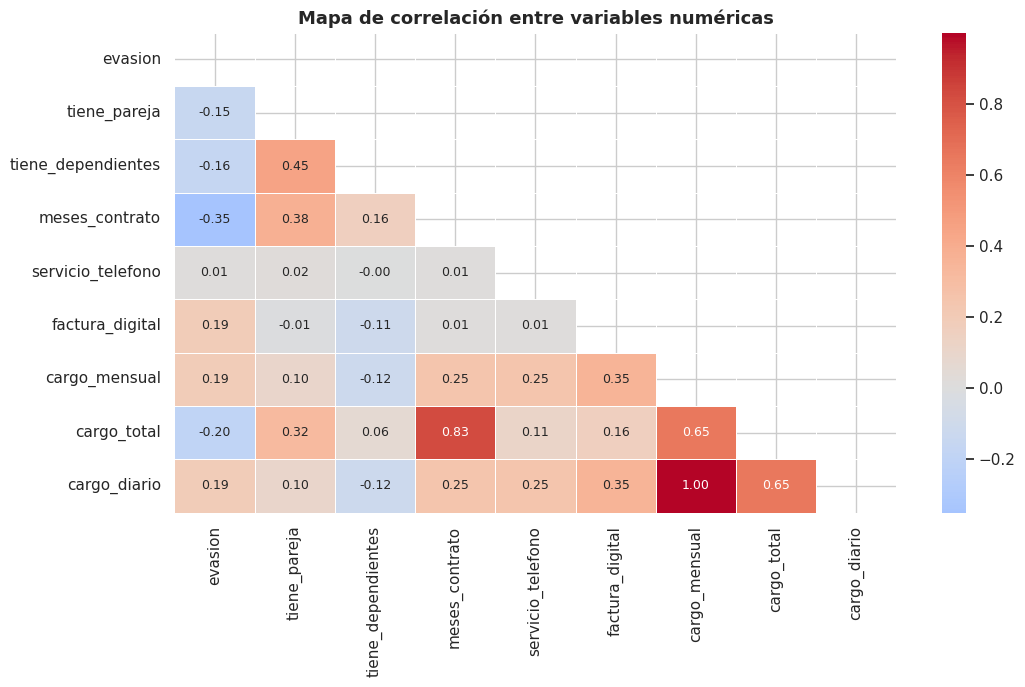

Correlaciones con evasión:
cargo_mensual         0.193
cargo_diario          0.193
factura_digital       0.192
servicio_telefono     0.012
tiene_pareja         -0.150
tiene_dependientes   -0.164
cargo_total          -0.198
meses_contrato       -0.352
Name: evasion, dtype: float64


In [17]:
df_num = df_limpio.select_dtypes(include=[np.number])
df_num = df_num.loc[:, df_num.nunique() > 1]

corr = df_num.corr()

fig, ax = plt.subplots(figsize=(11, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 9})
ax.set_title('Mapa de correlación entre variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('grafico_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

if 'evasion' in corr.columns:
    print("Correlaciones con evasión:")
    print(corr['evasion'].drop('evasion').sort_values(ascending=False).round(3))


---

## Informe Final

### Introducción

Telecom X tiene un problema real: demasiados clientes se están yendo. Según los datos analizados, más del 26% de la base cancela el servicio, lo que es una tasa bastante alta para cualquier empresa de telecomunicaciones. El objetivo de este análisis fue entender quiénes son esos clientes y qué tienen en común, para poder actuar antes de que se vayan.

---

### Limpieza y preparación de los datos

Los datos vinieron en formato JSON desde una API de GitHub. Al explorarlos, encontré algunos valores nulos en la columna de cargos totales (probablemente clientes nuevos que todavía no tienen historial de pagos), strings vacíos en algunas columnas y valores de texto con mayúsculas mezcladas.

Lo que hice fue:
- Normalizar todos los textos a minúsculas y sin espacios extra
- Reemplazar los nulos en cargos totales con 0
- Convertir la columna de cargos a tipo numérico, ya que venía como string
- Pasar las columnas yes/no a valores binarios (1 y 0)
- Traducir los nombres de columnas al español para que sea más fácil leer el análisis
- Crear una columna nueva llamada `cargo_diario` dividiendo el mensual entre 30

Al final no había duplicados y los datos quedaron bastante limpios para trabajar.

---

### Análisis Exploratorio de Datos

**Distribución general:**
De todos los clientes, el 26.5% se fue. Eso es 1 de cada 4 personas, lo cual es bastante preocupante si se piensa en términos de ingresos perdidos.

**Lo que encontré en las variables categóricas:**

El tipo de contrato fue lo que más me llamó la atención. Los clientes con contrato **mes a mes** tienen una tasa de evasión que supera el 40%, mientras que los que tienen contratos de 1 o 2 años prácticamente no se van. Parece que la flexibilidad que ofrece el contrato mensual también facilita que el cliente se vaya sin pensar mucho.

El tipo de internet también mostró diferencias: los usuarios de **fibra óptica** evaden más que los de DSL. Una posibilidad es que las expectativas son más altas con fibra y si el servicio no las cumple, el cliente se va más fácido.

En cuanto al método de pago, el **cheque electrónico** está asociado a mayor evasión. No es algo que cambie solo, pero podría ser un indicador de un perfil de cliente más desconectado de la empresa.

Los servicios adicionales como **soporte técnico** y **seguridad online** se asocian con menor evasión, lo cual tiene sentido: el cliente que usa más servicios tiene más razones para quedarse.

**Lo que mostró lo numérico:**

Hay una relación bastante clara entre los meses de contrato y la evasión. Los clientes nuevos (los primeros 12 meses) se van mucho más. Después de cierto tiempo, la tasa baja bastante. Esto sugiere que el período más crítico es el inicio de la relación.

El cargo mensual también es relevante: los que se fueron en promedio pagaban más que los que se quedaron. Esto puede indicar que hay clientes que sienten que no están recibiendo valor por lo que pagan.

---

### Conclusiones

- **El contrato mes a mes es el mayor factor de riesgo.** La empresa pierde a más de 4 de cada 10 clientes con ese tipo de contrato.
- **El primer año es clave.** Si un cliente llega al segundo año, la probabilidad de que se vaya baja bastante.
- **Precio sin valor percibido genera churn.** Cargos mensuales altos sin buenos servicios complementarios empujan a la salida.
- **Los servicios adicionales funcionan como ancla.** El cliente que contrata soporte o seguridad se queda más.

---

### Recomendaciones

1. **Ofrecer descuentos para migrar de mensual a anual** en los primeros 3 meses. Si el cliente acepta, la probabilidad de que se vaya cae enormemente.

2. **Diseñar un onboarding más activo.** Los primeros 90 días son críticos. Llamadas de seguimiento, tutoriales y contacto proactivo pueden marcar la diferencia.

3. **Crear paquetes que incluyan soporte técnico y seguridad** a un precio accesible. Esos servicios retienen, entonces conviene que más clientes los tengan.

4. **Revisar la experiencia del servicio de fibra óptica.** Si los clientes de fibra se van más, puede ser una señal de que la calidad no está cumpliendo las expectativas.

5. **Pensar en el segmento de adultos mayores por separado.** Tienen mayor tasa de evasión y probablemente necesitan un tipo de comunicación y soporte diferente.

Con estas variables (meses de contrato, tipo de contrato, cargo mensual y servicios adicionales) el equipo de Data Science tiene una base sólida para entrenar un modelo que prediga quién está por irse antes de que suceda.
